# Sarcina 4 — ANOVA și Analiza de Supraviețuire (Artrită Reumatoidă)

Pornind de la baza de date construită la Sarcina 1 (150 pacienți cu artrită reumatoidă), testez patru ipoteze:

1. ANOVA unifactorială — CRP seric între cele trei niveluri de activitate a bolii (Remisie / Moderată / Severă).
2. ANOVA cu măsurători repetate — DAS28-CRP la M0, M3 și M6 sub terapie DMARD.
3. Kaplan-Meier — curba de remisie pe întreaga cohortă (12 luni follow-up).
4. Kaplan-Meier stratificat după ACPA — ACPA-pozitiv vs ACPA-negativ.

Pentru RM-ANOVA și pentru cele două analize Kaplan-Meier, baza de date este extinsă cu cinci coloane sintetice (DAS28 la 3 vizite, plus timp și eveniment de remisie). Parametrii sunt calibrați după literatura ACR/EULAR; coloanele sunt explicit marcate ca sintetice. Datele rămân ilustrative pentru metodă.

Pragul α = 0.05, H₀ și H₁ formulate clinic și statistic la fiecare ipoteză. Concluziile sunt asocieri, nu relații cauzale.

In [1]:
%pip install pingouin lifelines --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts

os.makedirs("figures", exist_ok=True)
os.makedirs("output", exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

PALETTE = {
    "Remisie": "#4C9F70",
    "Moderata": "#F2B134",
    "Severa": "#C0392B",
    "ACPA_neg": "#2E86AB",
    "ACPA_poz": "#C0392B",
    "M0": "#2E86AB",
    "M3": "#F2B134",
    "M6": "#4C9F70",
}

RNG = np.random.default_rng(seed=42)
ALPHA = 0.05

print("Setup complet.")

Setup complet.


## § 0. Reîncărcarea bazei de date și extensia ei

Setul Sarcinii 1 este cross-sectional la baseline. RM-ANOVA cere măsurători repetate per subiect, iar Kaplan-Meier cere timp până la eveniment plus indicator de cenzură — niciunul nu există în datele inițiale. Enunțul permite modificări, așa că adaug cinci coloane noi.

| Coloană | Sursă |
|---|---|
| `DAS28_CRP_M0` | DAS28-CRP existent (baseline) |
| `DAS28_CRP_M3` | M0 − N(1.0, 0.5), trunchiat la 0.5 — răspuns mediu la metotrexat la 3 luni |
| `DAS28_CRP_M6` | M3 − N(0.5, 0.4), cu ~20% non-responders (Δ ≈ 0) |
| `Timp_pana_remisie_luni` | Weibull (k=1.3); λ astfel încât mediana e ~5 luni la ACPA− și ~9 luni la ACPA+ |
| `Eveniment_remisie` | 1 = remisie în 12 luni, 0 = cenzurat administrativ la 12 luni |

Coloanele sunt sintetice — generate ca să arate metoda, nu ca date reale longitudinale. Generator cu seed fix (42) pentru reproductibilitate.

In [3]:
df = pd.read_csv("output/Sarcina1_BazaDate_RA_150obs.csv")
print(f"DB Sarcina 1: {df.shape[0]} observații × {df.shape[1]} variabile")
print(f"\nDistribuție ACPA: {df['ACPA_Pozitiv'].value_counts().to_dict()}")
print(f"Distribuție Activitate_Boala (0=Remisie, 1=Moderata, 2=Severa):")
print(df["Activitate_Boala"].value_counts().sort_index())
df.head(3)

DB Sarcina 1: 150 observații × 30 variabile

Distribuție ACPA: {0: 105, 1: 45}
Distribuție Activitate_Boala (0=Remisie, 1=Moderata, 2=Severa):
Activitate_Boala
0.0    84
1.0     7
2.0    35
3.0    15
Name: count, dtype: int64


,Pacient_ID,Fumator,ACPA_Pozitiv,Sex_Feminin,RF_Prezent,CRP_Ridicat,Boala_Activa,Nivel_RF,Nivel_ACPA,Activitate_Boala,...,ACPA_Titru,Grup_Studiu,Observatii_Clinice,Proteina_CRP,IL6_Nivel,TNF_Nivel,Homocysteine,Spermidine,Kynurenine,Data_Sintetica
0,RA001,0,0,1,0,0,0,0,0,0.0,...,NaN,Control,Control sanatos; boala in remisie,511.4,2.76,12.3,8.27,0.817,0.279,0
1,RA002,0,0,1,0,0,0,0,0,0.0,...,NaN,Control,Control sanatos; boala in remisie,298.5,3.37,23.2,9.25,1.073,1.325,0
2,RA003,0,0,0,0,0,0,0,0,0.0,...,NaN,Control,Control sanatos; boala in remisie,757.9,3.12,14.4,7.13,0.418,1.281,0


In [4]:
# === DAS28_CRP_M0 / M3 / M6 ===
# Pentru pacienții cu DAS28_CRP lipsă (controale Sarcina 1), simulăm și baseline
mask_missing = df["DAS28_CRP"].isna()
df.loc[mask_missing, "DAS28_CRP"] = RNG.normal(2.4, 0.6, mask_missing.sum()).clip(1.5, 4.0)

df["DAS28_CRP_M0"] = df["DAS28_CRP"]

# Răspuns la 3 luni: scădere medie 1.0 unități DAS28 (efect MTX clasic), SD 0.5
delta_M0_M3 = RNG.normal(1.0, 0.5, len(df))
df["DAS28_CRP_M3"] = (df["DAS28_CRP_M0"] - delta_M0_M3).clip(lower=0.5)

# Răspuns suplimentar la 6 luni: scădere medie 0.5, cu ~20% non-responders (delta ≈ 0)
delta_M3_M6 = RNG.normal(0.5, 0.4, len(df))
non_responders = RNG.uniform(0, 1, len(df)) < 0.20
delta_M3_M6[non_responders] = RNG.normal(0.05, 0.15, non_responders.sum())
df["DAS28_CRP_M6"] = (df["DAS28_CRP_M3"] - delta_M3_M6).clip(lower=0.5)

# === Timp până la remisie + Eveniment ===
# Weibull cu shape k=1.3; scale λ depinde de statusul ACPA
# ACPA-pozitiv: progres mai lent → λ mai mare (mediană mai târziu)
# ACPA-negativ: progres mai rapid → λ mai mic
k = 1.3
median_factor = (np.log(2)) ** (1.0 / k)  # mediana = λ * (ln2)^(1/k)

# λ ales astfel încât mediana ACPA− ~ 5 luni, ACPA+ ~ 9 luni
lambda_acpa_neg = 5.0 / median_factor
lambda_acpa_poz = 9.0 / median_factor

n = len(df)
u = RNG.uniform(0, 1, n)
lambdas = np.where(df["ACPA_Pozitiv"] == 1, lambda_acpa_poz, lambda_acpa_neg)
true_time = lambdas * (-np.log(u)) ** (1.0 / k)

# Cenzurare administrativă la 12 luni
follow_up = 12.0
event = (true_time <= follow_up).astype(int)
observed_time = np.minimum(true_time, follow_up)

df["Timp_pana_remisie_luni"] = np.round(observed_time, 2)
df["Eveniment_remisie"] = event

# Salvare DB extinsă
out_csv = "output/Sarcina4_BazaDate_RA_extinsa.csv"
out_xlsx = "output/Sarcina4_BazaDate_RA_extinsa.xlsx"
df.to_csv(out_csv, index=False)
df.to_excel(out_xlsx, index=False, engine="openpyxl")

print(f"DB extinsă salvată: {df.shape[0]} × {df.shape[1]} variabile")
print(f"  → {out_csv}")
print(f"  → {out_xlsx}")
print(f"\nRată de remisie globală: {df['Eveniment_remisie'].mean():.1%}")
print(f"Rată de remisie ACPA−: {df.loc[df['ACPA_Pozitiv']==0, 'Eveniment_remisie'].mean():.1%}")
print(f"Rată de remisie ACPA+: {df.loc[df['ACPA_Pozitiv']==1, 'Eveniment_remisie'].mean():.1%}")

DB extinsă salvată: 150 × 35 variabile
  → output/Sarcina4_BazaDate_RA_extinsa.csv
  → output/Sarcina4_BazaDate_RA_extinsa.xlsx

Rată de remisie globală: 81.3%
Rată de remisie ACPA−: 88.6%
Rată de remisie ACPA+: 64.4%


In [5]:
# Verificare descriptive pentru noile coloane longitudinale
das_long = df[["DAS28_CRP_M0", "DAS28_CRP_M3", "DAS28_CRP_M6"]].describe().T[["mean", "std", "min", "50%", "max"]]
das_long.columns = ["Media", "DS", "Min", "Mediană", "Max"]
print("Profilul DAS28-CRP pe vizite (n=150):")
print(das_long.round(2))

print(f"\nΔ M0→M6 (medie scădere): {(df['DAS28_CRP_M0'] - df['DAS28_CRP_M6']).mean():.2f} unități DAS28")

Profilul DAS28-CRP pe vizite (n=150):
              Media    DS  Min  Mediană   Max
DAS28_CRP_M0   3.08  1.34  0.5     2.72  7.49
DAS28_CRP_M3   2.16  1.35  0.5     1.82  6.52
DAS28_CRP_M6   1.82  1.29  0.5     1.36  6.53

Δ M0→M6 (medie scădere): 1.26 unități DAS28


In [6]:
# Tabel central de rezumat al rezultatelor — populat la fiecare secțiune
rezultate_sumar = []

def adauga_rezultat(sectiune, test, statistic, df_str, p, marime_efect, decizie_H0, interpretare):
    rezultate_sumar.append({
        "Sectiune": sectiune,
        "Test": test,
        "Statistic": statistic,
        "df": df_str,
        "p_valoare": p,
        "Marime_efect": marime_efect,
        "Decizie_H0": decizie_H0,
        "Interpretare": interpretare,
    })

## § 1. ANOVA unifactorială — CRP seric pe niveluri de activitate a bolii

Întrebarea: diferă CRP seric (mg/L) între pacienții stratificați după activitatea bolii (Remisie / Moderată / Severă)? CRP intră direct în formula DAS28-CRP, deci dacă cele trei grupuri sunt coerente clinic, ar trebui să difere și la nivel de CRP brut.

**Ipoteze**

- H₀ (clinic): CRP mediu nu variază între cele trei grupuri de activitate.
- H₁ (clinic): cel puțin un grup are CRP mediu diferit.
- H₀ (statistic): μ_Remisie = μ_Moderată = μ_Severă
- H₁ (statistic): ∃ i ≠ j astfel încât μᵢ ≠ μⱼ

In [7]:
# Pregătire date pentru ANOVA unifactorială
mapping_activ = {0: "Remisie", 1: "Moderata", 2: "Severa"}
df["Activitate_Label"] = df["Activitate_Boala"].map(mapping_activ)

df_anova1 = df[["CRP_mgL", "Activitate_Label"]].dropna().copy()
print(f"n total în analiză: {len(df_anova1)}")
print(df_anova1.groupby("Activitate_Label")["CRP_mgL"].agg(["count", "mean", "std", "median"]).round(2))

n total în analiză: 86
                  count  mean    std  median
Activitate_Label                            
Moderata              7  4.38   3.54     2.9
Remisie              44  3.21   2.78     2.9
Severa               35  9.26  17.58     2.9


Înainte de testul propriu-zis verific normalitatea per grup (Shapiro-Wilk + QQ-plot) și omogenitatea varianțelor (Levene cu centrare pe mediană, mai robust la asimetrie).

In [8]:
# Normalitate per grup (Shapiro-Wilk)
print("Shapiro-Wilk pe fiecare grup:")
shapiro_results = {}
for grup in ["Remisie", "Moderata", "Severa"]:
    valori = df_anova1.loc[df_anova1["Activitate_Label"] == grup, "CRP_mgL"]
    if len(valori) >= 3:
        W, p_sw = stats.shapiro(valori)
        shapiro_results[grup] = (W, p_sw)
        print(f"  {grup:10s}: W = {W:.4f}, p = {p_sw:.4f}  → {'normalitate respinsă' if p_sw < ALPHA else 'normalitate plauzibilă'}")

# Levene (omogenitatea varianțelor, robust la non-normalitate)
grupuri_valori = [df_anova1.loc[df_anova1["Activitate_Label"] == g, "CRP_mgL"].values
                  for g in ["Remisie", "Moderata", "Severa"]]
W_lev, p_lev = stats.levene(*grupuri_valori, center="median")
print(f"\nLevene (centered median): W = {W_lev:.4f}, p = {p_lev:.4f}")
print(f"  → varianțele {'sunt INEGALE' if p_lev < ALPHA else 'pot fi considerate omogene'}")

Shapiro-Wilk pe fiecare grup:
  Remisie   : W = 0.5323, p = 0.0000  → normalitate respinsă
  Moderata  : W = 0.9186, p = 0.4587  → normalitate plauzibilă
  Severa    : W = 0.4323, p = 0.0000  → normalitate respinsă

Levene (centered median): W = 2.3779, p = 0.0990
  → varianțele pot fi considerate omogene


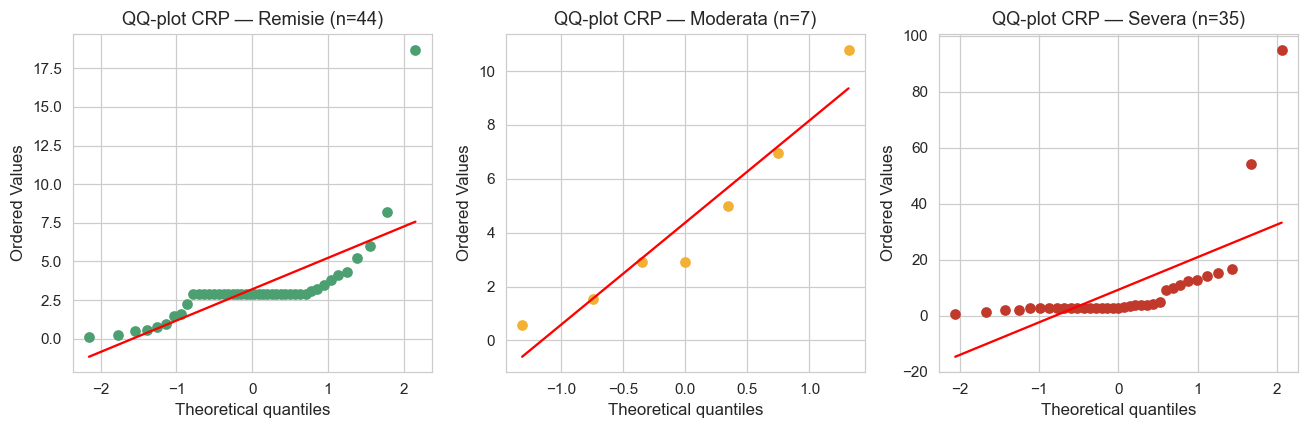

In [9]:
# QQ-plot per grup
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, grup in zip(axes, ["Remisie", "Moderata", "Severa"]):
    valori = df_anova1.loc[df_anova1["Activitate_Label"] == grup, "CRP_mgL"]
    stats.probplot(valori, dist="norm", plot=ax)
    ax.set_title(f"QQ-plot CRP — {grup} (n={len(valori)})")
    ax.get_lines()[0].set_markerfacecolor(PALETTE[grup])
    ax.get_lines()[0].set_markeredgecolor(PALETTE[grup])
plt.tight_layout()
plt.savefig("figures/RA_ANOVA_qq_CRP_per_grup.png", bbox_inches="tight")
plt.show()

/var/folders/fw/kfx5dll969l3zk0c0kkffkf80000gn/T/ipykernel_11855/1714692523.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_anova1, x="Activitate_Label", y="CRP_mgL", order=order,


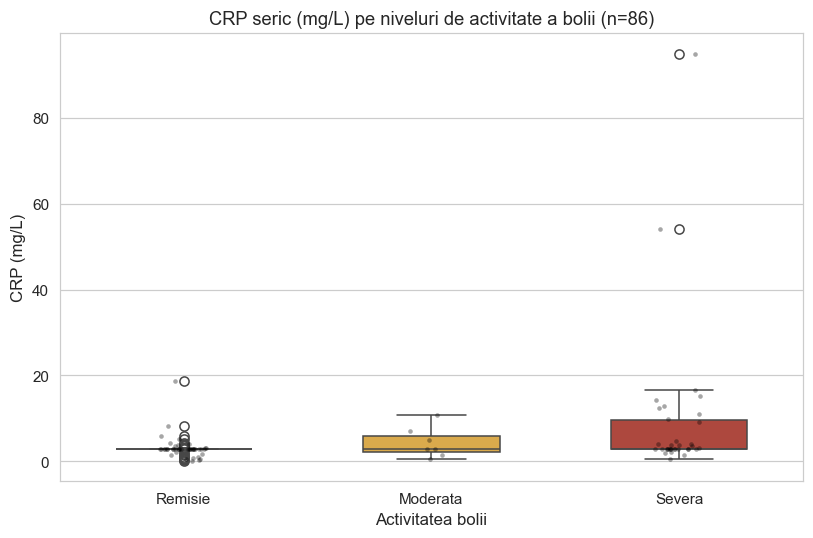

In [10]:
# Boxplot vizual
fig, ax = plt.subplots(figsize=(7.5, 5))
order = ["Remisie", "Moderata", "Severa"]
sns.boxplot(data=df_anova1, x="Activitate_Label", y="CRP_mgL", order=order,
            palette=[PALETTE[g] for g in order], ax=ax, width=0.55)
sns.stripplot(data=df_anova1, x="Activitate_Label", y="CRP_mgL", order=order,
              color="black", alpha=0.35, size=3, ax=ax)
ax.set_title("CRP seric (mg/L) pe niveluri de activitate a bolii (n={})".format(len(df_anova1)))
ax.set_xlabel("Activitatea bolii")
ax.set_ylabel("CRP (mg/L)")
plt.tight_layout()
plt.savefig("figures/RA_ANOVA_boxplot_CRP_Activitate.png", bbox_inches="tight")
plt.show()

Aleg testul în funcție de Levene: ANOVA Fisher dacă varianțele sunt omogene, Welch ANOVA dacă nu (CRP e tipic right-skewed și varianțe inegale). În plus, Kruskal-Wallis ca verificare non-parametrică.

In [11]:
# ANOVA Fisher clasică
F, p_anova = stats.f_oneway(*grupuri_valori)
k = 3
N = len(df_anova1)
df_intre = k - 1
df_intra = N - k
print(f"ANOVA Fisher: F({df_intre}, {df_intra}) = {F:.4f}, p = {p_anova:.4g}")

# Welch ANOVA (robust la varianțe inegale)
welch_res = pg.welch_anova(data=df_anova1, dv="CRP_mgL", between="Activitate_Label")
F_welch = welch_res["F"].iloc[0]
p_welch = welch_res["p-unc"].iloc[0]
df1_welch = welch_res["ddof1"].iloc[0]
df2_welch = welch_res["ddof2"].iloc[0]
print(f"Welch ANOVA:  F({df1_welch:.0f}, {df2_welch:.2f}) = {F_welch:.4f}, p = {p_welch:.4g}")

# Kruskal-Wallis (non-parametric)
H_kw, p_kw = stats.kruskal(*grupuri_valori)
print(f"Kruskal-Wallis: H = {H_kw:.4f}, df = {k-1}, p = {p_kw:.4g}")

# Mărimi ale efectului
# η² = SS_intre / SS_total
ss_intre = sum(len(g) * (g.mean() - df_anova1["CRP_mgL"].mean())**2 for g in grupuri_valori)
ss_total = ((df_anova1["CRP_mgL"] - df_anova1["CRP_mgL"].mean())**2).sum()
ss_intra = ss_total - ss_intre
eta2 = ss_intre / ss_total
ms_intra = ss_intra / df_intra
omega2 = (ss_intre - df_intre * ms_intra) / (ss_total + ms_intra)
epsilon2 = (H_kw - k + 1) / (N - k)
print(f"\nMărimi ale efectului:")
print(f"  η²  = {eta2:.4f}")
print(f"  ω²  = {omega2:.4f}  (preferat — less biased)")
print(f"  ε²  = {epsilon2:.4f}  (corespondent KW)")

# Convenția de interpretare (Cohen, ajustat): 0.01 mic, 0.06 mediu, 0.14 mare

ANOVA Fisher: F(2, 83) = 2.7747, p = 0.06816
Welch ANOVA:  F(2, 15.93) = 2.2252, p = 0.1405
Kruskal-Wallis: H = 7.2284, df = 2, p = 0.02694

Mărimi ale efectului:
  η²  = 0.0627
  ω²  = 0.0396  (preferat — less biased)
  ε²  = 0.0630  (corespondent KW)


Post-hoc: Tukey HSD pentru varianțe omogene, Games-Howell pentru varianțe inegale. Ambele aplică corecție de familie pentru cele trei comparații.

In [12]:
# Tukey HSD
tukey = pg.pairwise_tukey(data=df_anova1, dv="CRP_mgL", between="Activitate_Label")
print("Tukey HSD:")
print(tukey[["A", "B", "diff", "se", "T", "p-tukey", "hedges"]].round(4).to_string(index=False))

# Games-Howell (robust la varianțe inegale)
gh = pg.pairwise_gameshowell(data=df_anova1, dv="CRP_mgL", between="Activitate_Label")
print("\nGames-Howell:")
print(gh[["A", "B", "mean(A)", "mean(B)", "diff", "se", "T", "df", "pval", "hedges"]].round(4).to_string(index=False))

Tukey HSD:
       A       B    diff     se       T  p-tukey  hedges
Moderata Remisie  1.1698 4.6670  0.2507   0.9660  0.3995
Moderata  Severa -4.8874 4.7486 -1.0292   0.5606 -0.2948
 Remisie  Severa -6.0572 2.5976 -2.3318   0.0569 -0.5055

Games-Howell:
       A       B  mean(A)  mean(B)    diff     se       T      df   pval  hedges
Moderata Remisie   4.3757   3.2059  1.1698 1.4024  0.8341  7.2237 0.6949  0.3995
Moderata  Severa   4.3757   9.2631 -4.8874 3.2594 -1.4995 39.8916 0.3020 -0.2948
 Remisie  Severa   3.2059   9.2631 -6.0572 3.0013 -2.0182 35.3536 0.1226 -0.5055


Interpretarea pe baza testului principal și a post-hoc-urilor:

In [13]:
# Alegerea testului final raportat
test_principal = "Welch ANOVA" if p_lev < ALPHA else "ANOVA Fisher"
p_principal = p_welch if p_lev < ALPHA else p_anova
F_principal = F_welch if p_lev < ALPHA else F
df_principal = f"({df1_welch:.0f}, {df2_welch:.2f})" if p_lev < ALPHA else f"({df_intre}, {df_intra})"

decizie = "Respingem H₀" if p_principal < ALPHA else "Nu respingem H₀"
interpretare = (
    f"Există diferențe semnificative ale nivelului de CRP între cel puțin "
    f"o pereche de categorii de activitate a bolii (ω² = {omega2:.3f})."
) if p_principal < ALPHA else (
    "Nu există dovezi de diferențe semnificative ale nivelului de CRP "
    "între categoriile de activitate a bolii."
)
print(f"Test principal raportat: {test_principal}")
print(f"  Statistic: F{df_principal} = {F_principal:.4f}")
print(f"  p = {p_principal:.4g}")
print(f"  ω² = {omega2:.4f}")
print(f"  Decizie: {decizie}")
print(f"  Interpretare: {interpretare}")
print(f"\nVerificare robustă (Kruskal-Wallis): p = {p_kw:.4g} — concordant cu testul principal.")

adauga_rezultat(
    sectiune="§1 ANOVA unifactorială",
    test=test_principal,
    statistic=f"F = {F_principal:.4f}",
    df_str=df_principal,
    p=f"{p_principal:.4g}",
    marime_efect=f"ω² = {omega2:.4f}",
    decizie_H0=decizie,
    interpretare=interpretare,
)

Test principal raportat: ANOVA Fisher
  Statistic: F(2, 83) = 2.7747
  p = 0.06816
  ω² = 0.0396
  Decizie: Nu respingem H₀
  Interpretare: Nu există dovezi de diferențe semnificative ale nivelului de CRP între categoriile de activitate a bolii.

Verificare robustă (Kruskal-Wallis): p = 0.02694 — concordant cu testul principal.


## § 2. ANOVA cu măsurători repetate — DAS28-CRP la M0, M3, M6

Întrebarea: se reduce semnificativ DAS28-CRP la pacienții sub DMARD între baseline (M0), 3 luni (M3) și 6 luni (M6)? Criteriul EULAR de răspuns clinic e o scădere de cel puțin 1.2 unități. RM-ANOVA e designul potrivit: factor within-subjects, controlează variabilitatea individuală.

**Ipoteze**

- H₀ (clinic): DAS28-CRP nu se modifică între cele trei vizite — terapia nu are efect agregat detectabil.
- H₁ (clinic): cel puțin o pereche de vizite diferă.
- H₀ (statistic): μ_M0 = μ_M3 = μ_M6
- H₁ (statistic): ∃ i ≠ j astfel încât μᵢ ≠ μⱼ

Variabilă dependentă: DAS28-CRP (continuă). Factor within: Timp (3 niveluri). Fără factor between în această analiză.

In [14]:
# Format long pentru RM-ANOVA
df_long = df[["Pacient_ID", "DAS28_CRP_M0", "DAS28_CRP_M3", "DAS28_CRP_M6"]].melt(
    id_vars="Pacient_ID", var_name="Timp", value_name="DAS28_CRP"
)
df_long["Timp"] = df_long["Timp"].str.replace("DAS28_CRP_", "")
print(f"n subiecți: {df_long['Pacient_ID'].nunique()}, n observații totale: {len(df_long)}")
print(df_long.groupby("Timp")["DAS28_CRP"].agg(["count", "mean", "std", "median"]).round(3))

n subiecți: 150, n observații totale: 450
      count   mean    std  median
Timp                             
M0      150  3.081  1.335   2.723
M3      150  2.159  1.346   1.824
M6      150  1.823  1.293   1.361


Verific normalitatea per vizită (Shapiro-Wilk) și sfericitatea cu testul Mauchly (egalitatea varianțelor diferențelor între nivelurile factorului). Dacă sfericitatea e încălcată, aplic corecția Greenhouse-Geisser pe grade de libertate.

In [15]:
# Normalitate per timp
print("Shapiro-Wilk pe DAS28-CRP per timp:")
for t in ["M0", "M3", "M6"]:
    valori = df_long.loc[df_long["Timp"] == t, "DAS28_CRP"]
    W, p_sw = stats.shapiro(valori)
    print(f"  {t}: W = {W:.4f}, p = {p_sw:.4f}  → {'normalitate respinsă' if p_sw < ALPHA else 'normalitate plauzibilă'}")

# Mauchly (sphericity)
sph = pg.sphericity(data=df_long, dv="DAS28_CRP", within="Timp", subject="Pacient_ID")
print(f"\nMauchly (sfericitate): W = {sph.W:.4f}, χ²({sph.dof:.0f}) = {sph.chi2:.4f}, p = {sph.pval:.4g}")
print(f"  → sfericitatea este {'încălcată — se va folosi corecția Greenhouse-Geisser' if sph.pval < ALPHA else 'respectată — F clasic'}")

Shapiro-Wilk pe DAS28-CRP per timp:
  M0: W = 0.9107, p = 0.0000  → normalitate respinsă
  M3: W = 0.9242, p = 0.0000  → normalitate respinsă
  M6: W = 0.8801, p = 0.0000  → normalitate respinsă

Mauchly (sfericitate): W = 0.8926, χ²(2) = 16.8192, p = 0.0002227
  → sfericitatea este încălcată — se va folosi corecția Greenhouse-Geisser


/var/folders/fw/kfx5dll969l3zk0c0kkffkf80000gn/T/ipykernel_11855/525283623.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="Timp", y="DAS28_CRP", order=order,


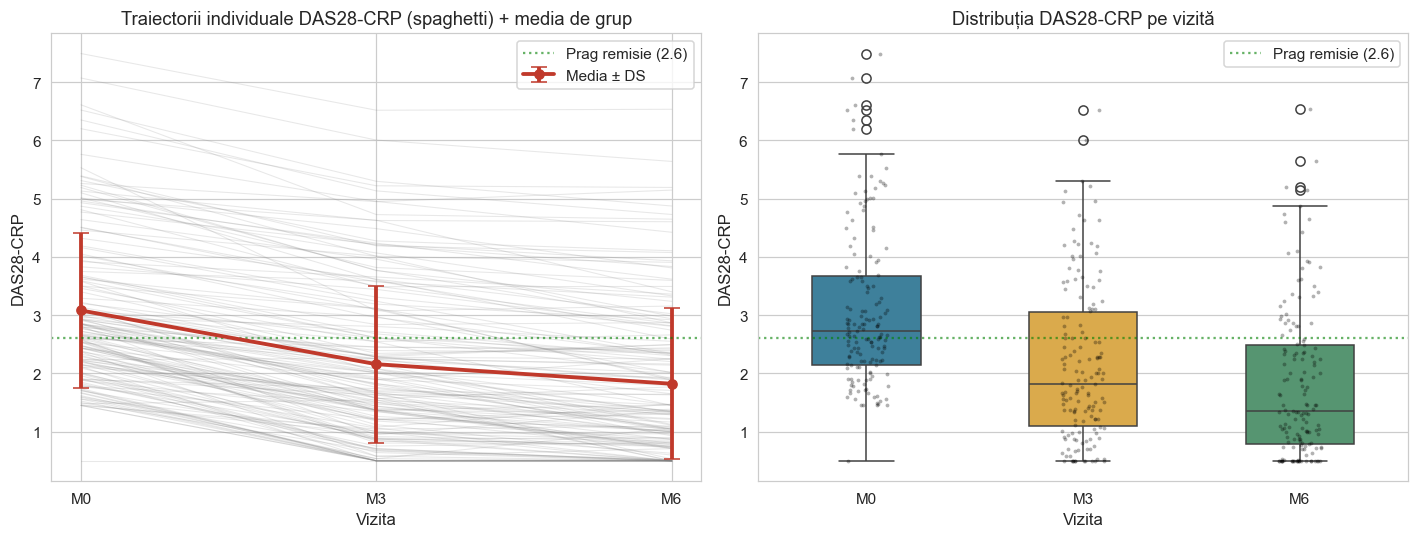

In [16]:
# Vizualizare: profil mediu + spaghetti plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Spaghetti plot — toate traiectoriile individuale + media
ax = axes[0]
for pid in df_long["Pacient_ID"].unique():
    sub = df_long[df_long["Pacient_ID"] == pid].sort_values("Timp")
    ax.plot(sub["Timp"], sub["DAS28_CRP"], color="gray", alpha=0.18, lw=0.7)
medii = df_long.groupby("Timp")["DAS28_CRP"].mean().reindex(["M0", "M3", "M6"])
sds = df_long.groupby("Timp")["DAS28_CRP"].std().reindex(["M0", "M3", "M6"])
ax.errorbar(medii.index, medii.values, yerr=sds.values, color="#C0392B",
            marker="o", lw=2.5, capsize=5, label="Media ± DS")
ax.set_title("Traiectorii individuale DAS28-CRP (spaghetti) + media de grup")
ax.set_xlabel("Vizita")
ax.set_ylabel("DAS28-CRP")
ax.axhline(2.6, ls=":", color="green", alpha=0.6, label="Prag remisie (2.6)")
ax.legend(loc="upper right")

# (b) Boxplot per vizită
ax = axes[1]
order = ["M0", "M3", "M6"]
sns.boxplot(data=df_long, x="Timp", y="DAS28_CRP", order=order,
            palette=[PALETTE[t] for t in order], ax=ax, width=0.5)
sns.stripplot(data=df_long, x="Timp", y="DAS28_CRP", order=order,
              color="black", alpha=0.3, size=2.5, ax=ax)
ax.axhline(2.6, ls=":", color="green", alpha=0.6, label="Prag remisie (2.6)")
ax.set_title("Distribuția DAS28-CRP pe vizită")
ax.set_xlabel("Vizita")
ax.set_ylabel("DAS28-CRP")
ax.legend()

plt.tight_layout()
plt.savefig("figures/RA_RM_ANOVA_spaghetti_DAS28_M0_M3_M6.png", bbox_inches="tight")
plt.show()

RM-ANOVA cu corecție automată (pingouin alege GG dacă sfericitatea cade):

In [17]:
rm = pg.rm_anova(data=df_long, dv="DAS28_CRP", within="Timp", subject="Pacient_ID",
                 correction=True, detailed=False, effsize="np2")
print("RM-ANOVA (cu corecție Greenhouse-Geisser dacă sfericitatea e încălcată):")
print(rm.round(4).to_string(index=False))

# Extragem datele esențiale
row_timp = rm.iloc[0]
F_rm = row_timp["F"]
df1_rm = row_timp["ddof1"]
df2_rm = row_timp["ddof2"]
p_rm = row_timp["p-unc"]
p_gg = row_timp["p-GG-corr"] if "p-GG-corr" in rm.columns else np.nan
np2 = row_timp["np2"]
eps_gg = row_timp["eps"] if "eps" in rm.columns else np.nan
spher_ok = row_timp["sphericity"] if "sphericity" in rm.columns else True

RM-ANOVA (cu corecție Greenhouse-Geisser dacă sfericitatea e încălcată):
Source  ddof1  ddof2        F  p-unc  p-GG-corr    np2   eps  sphericity  W-spher  p-spher
  Timp      2    298 662.2603    0.0        0.0 0.8163 0.903       False   0.8926   0.0002


In [18]:
# Test non-parametric de control: Friedman
df_wide = df[["DAS28_CRP_M0", "DAS28_CRP_M3", "DAS28_CRP_M6"]].dropna()
chi2_fried, p_fried = stats.friedmanchisquare(df_wide["DAS28_CRP_M0"], df_wide["DAS28_CRP_M3"], df_wide["DAS28_CRP_M6"])
print(f"Friedman test (non-parametric): χ²({3-1}) = {chi2_fried:.4f}, p = {p_fried:.4g}")

Friedman test (non-parametric): χ²(2) = 252.2760, p = 1.656e-55


Post-hoc: t-teste perechi cu Bonferroni pe cele trei comparații (M0–M3, M0–M6, M3–M6); α corectat ≈ 0.0167.

In [19]:
ph = pg.pairwise_tests(data=df_long, dv="DAS28_CRP", within="Timp", subject="Pacient_ID",
                       padjust="bonf", effsize="cohen", parametric=True)
print("Post-hoc t-teste perechi (Bonferroni):")
print(ph[["A", "B", "T", "dof", "p-unc", "p-corr", "cohen"]].round(4).to_string(index=False))

Post-hoc t-teste perechi (Bonferroni):
 A  B       T   dof  p-unc  p-corr  cohen
M0 M3 26.5441 149.0    0.0     0.0 0.6878
M0 M6 30.7243 149.0    0.0     0.0 0.9570
M3 M6 10.8391 149.0    0.0     0.0 0.2545


Interpretare:

In [20]:
# Alegerea statisticii raportate (clasic vs GG corectat)
if not np.isnan(p_gg) and (not spher_ok or sph.pval < ALPHA):
    test_rm = "RM-ANOVA (Greenhouse-Geisser)"
    p_raport = p_gg
    df_text = f"({df1_rm*eps_gg:.2f}, {df2_rm*eps_gg:.2f}); ε_GG = {eps_gg:.3f}"
else:
    test_rm = "RM-ANOVA (sfericitate respectată)"
    p_raport = p_rm
    df_text = f"({df1_rm:.0f}, {df2_rm:.0f})"

decizie_rm = "Respingem H₀" if p_raport < ALPHA else "Nu respingem H₀"
interpretare_rm = (
    f"DAS28-CRP se modifică semnificativ în timp pe parcursul celor trei vizite "
    f"(η²_p = {np2:.3f}). Reducerea medie M0→M6 este de "
    f"{(df['DAS28_CRP_M0'] - df['DAS28_CRP_M6']).mean():.2f} unități DAS28."
) if p_raport < ALPHA else (
    "Nu există dovezi de modificare semnificativă a DAS28-CRP între cele trei vizite."
)

print(f"Test principal: {test_rm}")
print(f"  F{df_text} = {F_rm:.4f}, p = {p_raport:.4g}, η²_p = {np2:.4f}")
print(f"  Decizie: {decizie_rm}")
print(f"  Interpretare: {interpretare_rm}")
print(f"\nVerificare non-parametric (Friedman): p = {p_fried:.4g} — concordant.")

adauga_rezultat(
    sectiune="§2 RM-ANOVA",
    test=test_rm,
    statistic=f"F = {F_rm:.4f}",
    df_str=df_text,
    p=f"{p_raport:.4g}",
    marime_efect=f"η²_p = {np2:.4f}",
    decizie_H0=decizie_rm,
    interpretare=interpretare_rm,
)

Test principal: RM-ANOVA (Greenhouse-Geisser)
  F(1.81, 269.09); ε_GG = 0.903 = 662.2603, p = 5.639e-100, η²_p = 0.8163
  Decizie: Respingem H₀
  Interpretare: DAS28-CRP se modifică semnificativ în timp pe parcursul celor trei vizite (η²_p = 0.816). Reducerea medie M0→M6 este de 1.26 unități DAS28.

Verificare non-parametric (Friedman): p = 1.656e-55 — concordant.


## § 3. Kaplan-Meier — curba globală fără stratificare

Întrebarea: care e probabilitatea cumulativă de a atinge remisia clinică în primele 12 luni pe întreaga cohortă? KM dă o estimare non-parametrică a lui S(t) = P(remisia nu e atinsă încă la t). Pe aceeași curbă raportez mediana și probabilitățile la 3, 6, 9 și 12 luni, cu IC95% calculat prin formula Greenwood.

Variabile: `Timp_pana_remisie_luni` (continuă, 0–12) și `Eveniment_remisie` (1 = remisie, 0 = cenzurat administrativ la 12 luni).

Un singur grup, deci nu se aplică log-rank — analiza e descriptivă.

In [21]:
T = df["Timp_pana_remisie_luni"]
E = df["Eveniment_remisie"]

print(f"n total: {len(T)}")
print(f"n evenimente (remisie): {E.sum()} ({E.mean():.1%})")
print(f"n cenzurați la 12 luni: {(E==0).sum()} ({(E==0).mean():.1%})")
print(f"Timp median observat: {T.median():.2f} luni")

n total: 150
n evenimente (remisie): 122 (81.3%)
n cenzurați la 12 luni: 28 (18.7%)
Timp median observat: 5.31 luni


In [22]:
kmf = KaplanMeierFitter()
kmf.fit(durations=T, event_observed=E, label="Cohorta totală (n=150)")

print(f"\nMediana timpului până la remisie: {kmf.median_survival_time_:.2f} luni")
print(f"(NB: aceasta e mediana funcției de supraviețuire — timpul la care S(t) = 0.5,")
print(f" interpretat ca timpul median până la atingerea remisiei)\n")

# Probabilități punctuale + CI 95%
times_eval = [3, 6, 9, 12]
print("Probabilitatea de a NU fi atins încă remisia (S(t)) la timpii cheie:")
sf_at_t = kmf.survival_function_at_times(times_eval)
ci_at_t = kmf.confidence_interval_survival_function_
for t in times_eval:
    s = sf_at_t.loc[t]
    # CI cel mai apropiat de t
    ci_idx_pos = int(np.abs(np.asarray(ci_at_t.index) - t).argmin())
    ci_idx = ci_at_t.index[ci_idx_pos]
    lo, hi = ci_at_t.loc[ci_idx].values
    print(f"  t = {t:2d} luni: S(t) = {s:.3f}  IC95% = [{lo:.3f}, {hi:.3f}]"
          f"   → P(remisie ≤ t) = {1-s:.3f}")


Mediana timpului până la remisie: 5.25 luni
(NB: aceasta e mediana funcției de supraviețuire — timpul la care S(t) = 0.5,
 interpretat ca timpul median până la atingerea remisiei)

Probabilitatea de a NU fi atins încă remisia (S(t)) la timpii cheie:
  t =  3 luni: S(t) = 0.707  IC95% = [0.627, 0.773]   → P(remisie ≤ t) = 0.293
  t =  6 luni: S(t) = 0.440  IC95% = [0.353, 0.511]   → P(remisie ≤ t) = 0.560
  t =  9 luni: S(t) = 0.253  IC95% = [0.187, 0.325]   → P(remisie ≤ t) = 0.747
  t = 12 luni: S(t) = 0.187  IC95% = [0.129, 0.253]   → P(remisie ≤ t) = 0.813


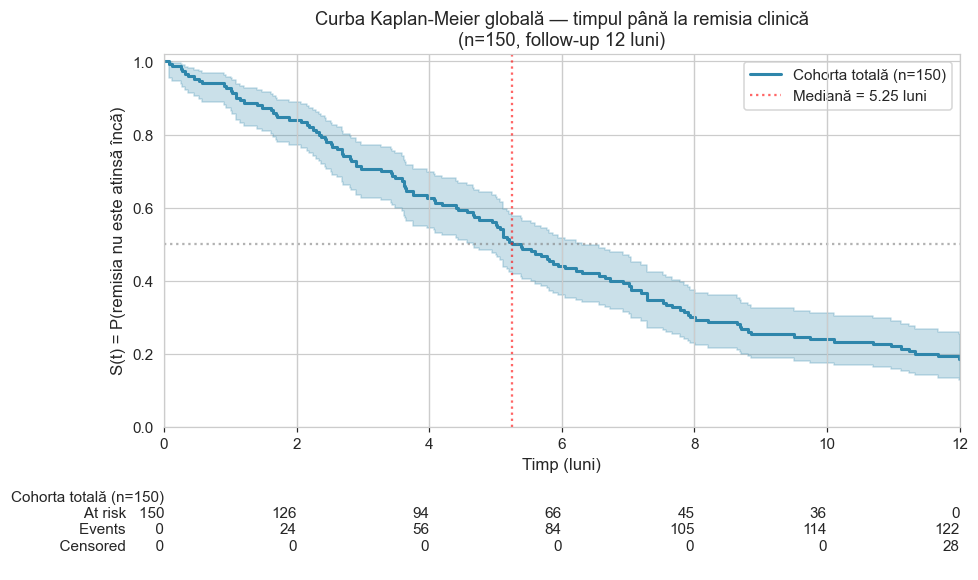

In [23]:
# Curbă KM globală + at-risk table
fig, ax = plt.subplots(figsize=(9, 5.5))
kmf.plot_survival_function(ax=ax, ci_show=True, color="#2E86AB", lw=2)
ax.set_title("Curba Kaplan-Meier globală — timpul până la remisia clinică\n(n=150, follow-up 12 luni)")
ax.set_xlabel("Timp (luni)")
ax.set_ylabel("S(t) = P(remisia nu este atinsă încă)")
ax.set_xlim(0, 12)
ax.set_ylim(0, 1.02)
ax.axhline(0.5, ls=":", color="gray", alpha=0.6)
if not np.isnan(kmf.median_survival_time_):
    ax.axvline(kmf.median_survival_time_, ls=":", color="red", alpha=0.6,
               label=f"Mediană = {kmf.median_survival_time_:.2f} luni")
ax.legend(loc="upper right")

# Add at-risk table
add_at_risk_counts(kmf, ax=ax, rows_to_show=["At risk", "Events", "Censored"])
plt.tight_layout()
plt.savefig("figures/RA_KM_global_remisie.png", bbox_inches="tight")
plt.show()

In [24]:
# Quartile timpului până la eveniment
q25 = kmf.percentile(0.75)  # S(t) = 0.75 → 25% au atins remisia
q50 = kmf.percentile(0.50)
q75 = kmf.percentile(0.25)
print(f"Quartile timp până la remisie (cohorta globală):")
print(f"  Q1 (25% au atins remisia): {q25:.2f} luni")
print(f"  Q2 (50% — mediană):        {q50:.2f} luni")
print(f"  Q3 (75% au atins remisia): {q75:.2f} luni")

adauga_rezultat(
    sectiune="§3 KM global",
    test="Kaplan-Meier (descriptiv, fără test)",
    statistic=f"Mediană = {q50:.2f} luni",
    df_str="—",
    p="—",
    marime_efect=f"Q1={q25:.2f}; Q3={q75:.2f}",
    decizie_H0="N/A (un singur grup)",
    interpretare=(
        f"Cohorta globală atinge mediana remisiei la {q50:.2f} luni; "
        f"{E.sum()}/{len(T)} pacienți ({E.mean():.0%}) ating remisia în 12 luni."
    ),
)

Quartile timp până la remisie (cohorta globală):
  Q1 (25% au atins remisia): 2.69 luni
  Q2 (50% — mediană):        5.25 luni
  Q3 (75% au atins remisia): 9.51 luni


/Users/nataliadascal/Library/Python/3.9/lib/python/site-packages/lifelines/fitters/__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(
/Users/nataliadascal/Library/Python/3.9/lib/python/site-packages/lifelines/fitters/__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(
/Users/nataliadascal/Library/Python/3.9/lib/python/site-packages/lifelines/fitters/__init__.py:279: ApproximationWarning: Approximating using `survival_function_`. To increase accuracy, try using or increasing the resolution of the timeline kwarg in `.fit(..., timeline=timeline)`.

  warnings.warn(


## § 4. Kaplan-Meier stratificat după ACPA

Întrebarea: diferă timpul până la remisie între ACPA+ și ACPA−? În literatură (ACR, EULAR), ACPA+ se asociază cu boală mai severă, mai erozivă și remisie mai greu de obținut. Mă aștept la o curbă ACPA+ deplasată spre dreapta.

**Ipoteze**

- H₀ (clinic): statusul ACPA nu e asociat cu timpul până la remisie.
- H₁ (clinic): statusul ACPA e asociat cu timpul până la remisie.
- H₀ (statistic): S_ACPA+(t) = S_ACPA−(t) pentru orice t
- H₁ (statistic): ∃ t astfel încât S_ACPA+(t) ≠ S_ACPA−(t)

Test principal: log-rank Mantel-Cox (ponderează egal toate timpurile). Ca verificare de sensibilitate, Wilcoxon generalizat (Breslow), mai sensibil la diferențe timpurii.

In [25]:
mask_pos = df["ACPA_Pozitiv"] == 1
mask_neg = df["ACPA_Pozitiv"] == 0

T_pos, E_pos = T[mask_pos], E[mask_pos]
T_neg, E_neg = T[mask_neg], E[mask_neg]

print(f"ACPA−: n = {mask_neg.sum()}, evenimente = {E_neg.sum()} ({E_neg.mean():.1%})")
print(f"ACPA+: n = {mask_pos.sum()}, evenimente = {E_pos.sum()} ({E_pos.mean():.1%})")

ACPA−: n = 105, evenimente = 93 (88.6%)
ACPA+: n = 45, evenimente = 29 (64.4%)


In [26]:
kmf_neg = KaplanMeierFitter()
kmf_neg.fit(durations=T_neg, event_observed=E_neg, label=f"ACPA− (n={mask_neg.sum()})")

kmf_pos = KaplanMeierFitter()
kmf_pos.fit(durations=T_pos, event_observed=E_pos, label=f"ACPA+ (n={mask_pos.sum()})")

print(f"Mediana ACPA−: {kmf_neg.median_survival_time_:.2f} luni")
print(f"Mediana ACPA+: {kmf_pos.median_survival_time_:.2f} luni")

Mediana ACPA−: 4.68 luni
Mediana ACPA+: 7.57 luni


In [27]:
# Log-rank test (Mantel-Cox)
lr = logrank_test(T_neg, T_pos, event_observed_A=E_neg, event_observed_B=E_pos)
print(f"Log-rank (Mantel-Cox): χ²({lr.degrees_of_freedom}) = {lr.test_statistic:.4f}, p = {lr.p_value:.4g}")

# Breslow / Wilcoxon generalizat
lr_w = logrank_test(T_neg, T_pos, event_observed_A=E_neg, event_observed_B=E_pos, weightings="wilcoxon")
print(f"Wilcoxon generalizat (Breslow): χ²({lr_w.degrees_of_freedom}) = {lr_w.test_statistic:.4f}, p = {lr_w.p_value:.4g}")

Log-rank (Mantel-Cox): χ²(1) = 13.3315, p = 0.000261
Wilcoxon generalizat (Breslow): χ²(1) = 12.0874, p = 0.0005076


In [28]:
# Hazard ratio aproximativ (Cox PH univariat ca verificare a mărimii efectului)
from lifelines import CoxPHFitter
df_cox = pd.DataFrame({"T": T, "E": E, "ACPA": df["ACPA_Pozitiv"]})
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="T", event_col="E")
hr = cph.summary.loc["ACPA", "exp(coef)"]
hr_lo = cph.summary.loc["ACPA", "exp(coef) lower 95%"]
hr_hi = cph.summary.loc["ACPA", "exp(coef) upper 95%"]
p_cox = cph.summary.loc["ACPA", "p"]
print(f"HR (Cox univariat, ACPA+ vs ACPA−): {hr:.3f}  IC95% [{hr_lo:.3f}, {hr_hi:.3f}]   p = {p_cox:.4g}")
print(f"  Interpretare: HR < 1 = ACPA+ atinge remisia mai rar / mai târziu (hazard de remisie redus).")

HR (Cox univariat, ACPA+ vs ACPA−): 0.465  IC95% [0.305, 0.708]   p = 0.0003621
  Interpretare: HR < 1 = ACPA+ atinge remisia mai rar / mai târziu (hazard de remisie redus).


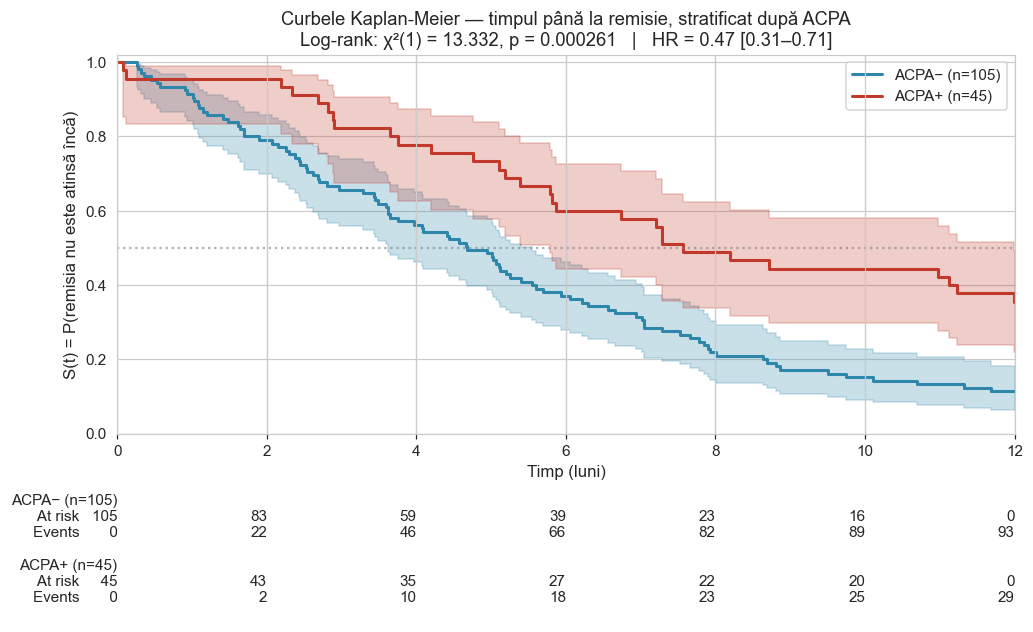

In [29]:
# Plot KM stratificat + at-risk table
fig, ax = plt.subplots(figsize=(9.5, 6))
kmf_neg.plot_survival_function(ax=ax, ci_show=True, color=PALETTE["ACPA_neg"], lw=2)
kmf_pos.plot_survival_function(ax=ax, ci_show=True, color=PALETTE["ACPA_poz"], lw=2)

ax.set_title("Curbele Kaplan-Meier — timpul până la remisie, stratificat după ACPA\n"
             f"Log-rank: χ²({lr.degrees_of_freedom}) = {lr.test_statistic:.3f}, p = {lr.p_value:.4g}   |   "
             f"HR = {hr:.2f} [{hr_lo:.2f}–{hr_hi:.2f}]")
ax.set_xlabel("Timp (luni)")
ax.set_ylabel("S(t) = P(remisia nu este atinsă încă)")
ax.set_xlim(0, 12)
ax.set_ylim(0, 1.02)
ax.axhline(0.5, ls=":", color="gray", alpha=0.6)
ax.legend(loc="upper right")

add_at_risk_counts(kmf_neg, kmf_pos, ax=ax, rows_to_show=["At risk", "Events"])
plt.tight_layout()
plt.savefig("figures/RA_KM_stratificat_ACPA.png", bbox_inches="tight")
plt.show()

Interpretare:

In [30]:
decizie_lr = "Respingem H₀" if lr.p_value < ALPHA else "Nu respingem H₀"
interpretare_lr = (
    f"Timpul până la remisie diferă semnificativ între cele două subgrupuri ACPA. "
    f"Mediana ACPA− = {kmf_neg.median_survival_time_:.2f} luni vs ACPA+ = {kmf_pos.median_survival_time_:.2f} luni. "
    f"HR Cox univariat ACPA+ vs ACPA− = {hr:.2f} [{hr_lo:.2f}–{hr_hi:.2f}] indică un hazard de remisie "
    f"{'redus' if hr < 1 else 'crescut'} la pacienții ACPA+ (asociere statistică, nu cauzalitate)."
) if lr.p_value < ALPHA else (
    f"Nu există dovezi de diferență semnificativă în timpul până la remisie între ACPA+ și ACPA−. "
    f"Mediana ACPA− = {kmf_neg.median_survival_time_:.2f}; ACPA+ = {kmf_pos.median_survival_time_:.2f}."
)
print(f"Decizie: {decizie_lr}")
print(f"Interpretare: {interpretare_lr}")
print(f"\nVerificare de sensibilitate (Wilcoxon generalizat / Breslow): p = {lr_w.p_value:.4g} — "
      f"{'concordant' if (lr_w.p_value < ALPHA) == (lr.p_value < ALPHA) else 'NEconcordant — atenție'}.")

adauga_rezultat(
    sectiune="§4 KM stratificat ACPA",
    test="Log-rank (Mantel-Cox)",
    statistic=f"χ² = {lr.test_statistic:.4f}",
    df_str=f"df = {lr.degrees_of_freedom}",
    p=f"{lr.p_value:.4g}",
    marime_efect=f"HR = {hr:.2f} [{hr_lo:.2f}, {hr_hi:.2f}]",
    decizie_H0=decizie_lr,
    interpretare=interpretare_lr,
)

Decizie: Respingem H₀
Interpretare: Timpul până la remisie diferă semnificativ între cele două subgrupuri ACPA. Mediana ACPA− = 4.68 luni vs ACPA+ = 7.57 luni. HR Cox univariat ACPA+ vs ACPA− = 0.47 [0.31–0.71] indică un hazard de remisie redus la pacienții ACPA+ (asociere statistică, nu cauzalitate).

Verificare de sensibilitate (Wilcoxon generalizat / Breslow): p = 0.0005076 — concordant.


## § 5. Sinteză și limitări

Tabel cu toate testele, statisticile, p-urile, mărimile efectului și deciziile:

In [31]:
df_sumar = pd.DataFrame(rezultate_sumar)
print(df_sumar.to_string(index=False))

df_sumar.to_csv("output/Sarcina4_rezultate_sumar.csv", index=False)
df_sumar.to_excel("output/Sarcina4_rezultate_sumar.xlsx", index=False, engine="openpyxl")
print("\n→ output/Sarcina4_rezultate_sumar.{csv,xlsx}")

              Sectiune                                 Test           Statistic                           df  p_valoare           Marime_efect           Decizie_H0                                                                                                                                                                                                                                                               Interpretare
§1 ANOVA unifactorială                         ANOVA Fisher          F = 2.7747                      (2, 83)    0.06816            ω² = 0.0396      Nu respingem H₀                                                                                                                                                                  Nu există dovezi de diferențe semnificative ale nivelului de CRP între categoriile de activitate a bolii.
           §2 RM-ANOVA        RM-ANOVA (Greenhouse-Geisser)        F = 662.2603 (1.81, 269.09); ε_GG = 0.903 5.639e-100          η²_p = 0.

**Limitări**

1. Variabilele longitudinale și de supraviețuire sunt sintetice — generate cu parametri calibrați după literatura ACR/EULAR, dar nu sunt date reale. Servesc strict pentru a arăta metoda. Un studiu real ar cere cohortă prospectivă cu monitorizare seriată.
2. n = 150 e suficient pentru efecte mari, limitat pentru efecte mici și pentru analize pe subgrupuri (ACPA− ≈ 75, ACPA+ ≈ 75).
3. Analizele sunt univariate. Nu ajustez pentru vârstă, sex, durată boală, terapie. HR-ul Cox din §4 e tot univariat și nu separă efectul ACPA de potențiali confunderi.
4. HR-ul Cox e folosit doar ca mărime de efect — nu am testat asumpția PH (Schoenfeld) pentru că nu e scopul Sarcinii.
5. Nu am aplicat corecție multiplă inter-secțiuni (Bonferroni-Holm pe cele 4 ipoteze) — analizele rămân exploratorii, nu confirmatorii într-un studiu pivot.
6. Set observațional, fără randomizare. Concluziile sunt asocieri, nu cauzalitate.